# Concrete Strength Optimizers

In [1]:
import glob, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fmin_l_bfgs_b
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
HIDDEN_DIM = 6
REG = 1e-4
COMMON_MAX_ITER = 100
GD_LR = 0.02
GD_GRAD_CLIP = 5.0
GN_DAMPING = 1e-2
TEST_SIZE = 0.15
VAL_SIZE_FROM_REST = 15 / 85
USE_EARLY_STOPPING = True
ES_PATIENCE = 10
ES_MIN_DELTA = 1e-5

WORKING_DIR = Path("/kaggle/working")
PLOTS_DIR = WORKING_DIR / "plots"
WORKING_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)

In [2]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    return float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100.0)

def find_dataset_file():
    files = []
    for pattern in ["/kaggle/input/**/*.csv", "/kaggle/input/**/*.xls", "/kaggle/input/**/*.xlsx"]:
        files.extend(glob.glob(pattern, recursive=True))
    if not files:
        raise FileNotFoundError("Upload dataset Concrete Compressive Strength ke Kaggle input.")
    preferred = [f for f in files if any(k in f.lower() for k in ["concrete", "compressive", "strength"])]
    return Path(preferred[0] if preferred else files[0])

def load_data():
    path = find_dataset_file()
    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path)
    else:
        df = pd.read_excel(path)
    df.columns = [str(c).strip() for c in df.columns]
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna().reset_index(drop=True)
    target_candidates = [c for c in df.columns if "compressive strength" in c.lower() or c.lower().strip() == "strength"]
    target_col = target_candidates[0] if target_candidates else df.columns[-1]
    feature_cols = [c for c in df.columns if c != target_col]
    return df, feature_cols, target_col, path

df, feature_cols, target_col, dataset_path = load_data()
X = df[feature_cols].values.astype(np.float64)
y = df[target_col].values.astype(np.float64)

X_train_rest, X_test, y_train_rest, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_rest, y_train_rest, test_size=VAL_SIZE_FROM_REST, random_state=RANDOM_STATE
)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_s = x_scaler.fit_transform(X_train)
X_val_s = x_scaler.transform(X_val)
X_test_s = x_scaler.transform(X_test)

y_train_s = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_s = y_scaler.transform(y_val.reshape(-1, 1)).ravel()
y_test_s = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

d = X_train_s.shape[1]
h = HIDDEN_DIM
n_params = d * h + h + h + 1
theta0 = rng.normal(0.0, 0.10, size=n_params)

split_info = pd.DataFrame({
    "split": ["train", "val", "test"],
    "n": [len(X_train), len(X_val), len(X_test)],
    "pct": [len(X_train)/len(df), len(X_val)/len(df), len(X_test)/len(df)]
})
display(split_info)

,split,n,pct
0,train,720,0.699029
1,val,155,0.150485
2,test,155,0.150485


In [3]:
class EarlyStopLBFGS(Exception):
    pass

def unpack_params(theta, d, h):
    i = 0
    W1 = theta[i:i+d*h].reshape(d, h); i += d*h
    b1 = theta[i:i+h]; i += h
    W2 = theta[i:i+h].reshape(h, 1); i += h
    b2 = theta[i]
    return W1, b1, W2, b2

def forward(theta, X, d, h):
    W1, b1, W2, b2 = unpack_params(theta, d, h)
    Z = X @ W1 + b1
    H = np.tanh(Z)
    y_hat = (H @ W2 + b2).ravel()
    return y_hat, H

def predict(theta, X, d, h):
    return forward(theta, X, d, h)[0]

def residual_and_jacobian(theta, X, y, d, h):
    W1, b1, W2, b2 = unpack_params(theta, d, h)
    Z = X @ W1 + b1
    H = np.tanh(Z)
    y_hat = (H @ W2 + b2).ravel()
    r = y_hat - y
    sech2 = 1.0 - H ** 2
    J = np.zeros((X.shape[0], theta.size), dtype=np.float64)
    idx = 0
    for fi in range(d):
        for hi in range(h):
            J[:, idx] = W2[hi, 0] * sech2[:, hi] * X[:, fi]
            idx += 1
    for hi in range(h):
        J[:, idx] = W2[hi, 0] * sech2[:, hi]
        idx += 1
    for hi in range(h):
        J[:, idx] = H[:, hi]
        idx += 1
    J[:, idx] = 1.0
    return r, J

def loss_grad(theta, X, y, d, h, reg=0.0):
    n = X.shape[0]
    W1, b1, W2, b2 = unpack_params(theta, d, h)
    Z = X @ W1 + b1
    H = np.tanh(Z)
    y_hat = (H @ W2 + b2).ravel()
    r = y_hat - y
    loss = float(np.mean(r ** 2) + reg * np.sum(theta ** 2))
    sech2 = 1.0 - H ** 2
    dy = (2.0 / n) * r[:, None]
    grad_W2 = H.T @ dy + 2.0 * reg * W2
    grad_b2 = float(dy.sum() + 2.0 * reg * b2)
    dH = dy @ W2.T
    dZ = dH * sech2
    grad_W1 = X.T @ dZ + 2.0 * reg * W1
    grad_b1 = dZ.sum(axis=0) + 2.0 * reg * b1
    grad = np.concatenate([grad_W1.ravel(), grad_b1.ravel(), grad_W2.ravel(), np.array([grad_b2])])
    return loss, grad

def update_best(theta, val_loss, best):
    if val_loss < best["val_loss"] - ES_MIN_DELTA:
        best["val_loss"] = float(val_loss)
        best["theta"] = theta.copy()
        best["wait"] = 0
    else:
        best["wait"] += 1

def train_gd(X_train, y_train, X_val, y_val, d, h, theta0):
    theta = theta0.copy()
    best = {"theta": theta.copy(), "val_loss": np.inf, "wait": 0}
    rows = []
    t0 = time.time()
    for it in range(1, COMMON_MAX_ITER + 1):
        train_loss, grad = loss_grad(theta, X_train, y_train, d, h, REG)
        grad_norm = float(np.linalg.norm(grad))
        if grad_norm > GD_GRAD_CLIP:
            grad = grad * (GD_GRAD_CLIP / (grad_norm + 1e-12))
            grad_norm = float(np.linalg.norm(grad))
        theta = theta - GD_LR * grad
        val_loss, _ = loss_grad(theta, X_val, y_val, d, h, REG)
        rows.append(["Gradient Descent", it, train_loss, val_loss, grad_norm, time.time() - t0])
        update_best(theta, val_loss, best)
        if USE_EARLY_STOPPING and best["wait"] >= ES_PATIENCE:
            break
    return best["theta"], pd.DataFrame(rows, columns=["optimizer", "iteration", "train_loss", "val_loss", "step_norm", "elapsed_sec"])

def train_gauss_newton(X_train, y_train, X_val, y_val, d, h, theta0):
    theta = theta0.copy()
    best = {"theta": theta.copy(), "val_loss": np.inf, "wait": 0}
    rows = []
    t0 = time.time()
    n = X_train.shape[0]
    for it in range(1, COMMON_MAX_ITER + 1):
        r, J = residual_and_jacobian(theta, X_train, y_train, d, h)
        A = (J.T @ J) / n + (GN_DAMPING + REG) * np.eye(theta.size)
        g = (J.T @ r) / n + REG * theta
        step = np.linalg.solve(A, g)
        train_loss = float(np.mean(r ** 2) + REG * np.sum(theta ** 2))
        theta = theta - step
        val_loss, _ = loss_grad(theta, X_val, y_val, d, h, REG)
        rows.append(["Gauss-Newton", it, train_loss, val_loss, float(np.linalg.norm(step)), time.time() - t0])
        update_best(theta, val_loss, best)
        if USE_EARLY_STOPPING and best["wait"] >= ES_PATIENCE:
            break
    return best["theta"], pd.DataFrame(rows, columns=["optimizer", "iteration", "train_loss", "val_loss", "step_norm", "elapsed_sec"])

def train_lbfgs(X_train, y_train, X_val, y_val, d, h, theta0):
    rows = []
    t0 = time.time()
    counter = {"i": 0}
    best = {"theta": theta0.copy(), "val_loss": np.inf, "wait": 0}

    def func(theta):
        loss, grad = loss_grad(theta, X_train, y_train, d, h, REG)
        return loss, grad.astype(np.float64)

    def callback(theta):
        counter["i"] += 1
        train_loss, grad = loss_grad(theta, X_train, y_train, d, h, REG)
        val_loss, _ = loss_grad(theta, X_val, y_val, d, h, REG)
        rows.append(["L-BFGS", counter["i"], train_loss, val_loss, float(np.linalg.norm(grad)), time.time() - t0])
        update_best(theta, val_loss, best)
        if USE_EARLY_STOPPING and best["wait"] >= ES_PATIENCE:
            raise EarlyStopLBFGS()

    try:
        theta, _, _ = fmin_l_bfgs_b(func=func, x0=theta0.copy(), maxiter=COMMON_MAX_ITER, callback=callback)
    except EarlyStopLBFGS:
        theta = best["theta"].copy()
    hist = pd.DataFrame(rows, columns=["optimizer", "iteration", "train_loss", "val_loss", "step_norm", "elapsed_sec"])
    if hist.empty:
        train_loss, grad = loss_grad(theta, X_train, y_train, d, h, REG)
        val_loss, _ = loss_grad(theta, X_val, y_val, d, h, REG)
        hist = pd.DataFrame([["L-BFGS", 1, train_loss, val_loss, float(np.linalg.norm(grad)), time.time() - t0]], columns=["optimizer", "iteration", "train_loss", "val_loss", "step_norm", "elapsed_sec"])
        update_best(theta, val_loss, best)
    return best["theta"], hist

def inverse_y(y_scaled):
    return y_scaler.inverse_transform(np.asarray(y_scaled).reshape(-1, 1)).ravel()

def evaluate(name, theta):
    p_train = inverse_y(predict(theta, X_train_s, d, h))
    p_val = inverse_y(predict(theta, X_val_s, d, h))
    p_test = inverse_y(predict(theta, X_test_s, d, h))
    yt_train = inverse_y(y_train_s)
    yt_val = inverse_y(y_val_s)
    yt_test = inverse_y(y_test_s)
    metrics = {
        "optimizer": name,
        "iteration_budget": COMMON_MAX_ITER,
        "train_rmse": rmse(yt_train, p_train),
        "val_rmse": rmse(yt_val, p_val),
        "test_rmse": rmse(yt_test, p_test),
        "test_mae": float(mean_absolute_error(yt_test, p_test)),
        "test_r2": float(r2_score(yt_test, p_test)),
        "test_mape": mape(yt_test, p_test),
    }
    preds = pd.DataFrame({
        "split": ["train"] * len(yt_train) + ["val"] * len(yt_val) + ["test"] * len(yt_test),
        "optimizer": name,
        "y_true": np.concatenate([yt_train, yt_val, yt_test]),
        "y_pred": np.concatenate([p_train, p_val, p_test]),
    })
    preds["residual"] = preds["y_true"] - preds["y_pred"]
    return metrics, preds

In [4]:
t0 = time.time()
gd_theta, gd_hist = train_gd(X_train_s, y_train_s, X_val_s, y_val_s, d, h, theta0)
gd_time = time.time() - t0

t0 = time.time()
gn_theta, gn_hist = train_gauss_newton(X_train_s, y_train_s, X_val_s, y_val_s, d, h, theta0)
gn_time = time.time() - t0

t0 = time.time()
lbfgs_theta, lbfgs_hist = train_lbfgs(X_train_s, y_train_s, X_val_s, y_val_s, d, h, theta0)
lbfgs_time = time.time() - t0

history_df = pd.concat([gd_hist, gn_hist, lbfgs_hist], ignore_index=True)

summary_rows = []
prediction_rows = []

for name, theta, hist, fit_time in [
    ("Gradient Descent", gd_theta, gd_hist, gd_time),
    ("Gauss-Newton", gn_theta, gn_hist, gn_time),
    ("L-BFGS", lbfgs_theta, lbfgs_hist, lbfgs_time),
]:
    metrics, preds = evaluate(name, theta)
    metrics["n_iterations"] = int(hist["iteration"].max())
    metrics["fit_time_sec"] = float(fit_time)
    summary_rows.append(metrics)
    prediction_rows.append(preds)

summary_df = pd.DataFrame(summary_rows).sort_values("test_rmse").reset_index(drop=True)
predictions_df = pd.concat(prediction_rows, ignore_index=True)

history_df.to_csv(WORKING_DIR / "optimizer_history.csv", index=False)
summary_df.to_csv(WORKING_DIR / "optimizer_summary.csv", index=False)
predictions_df.to_csv(WORKING_DIR / "all_predictions_and_residuals.csv", index=False)

pd.DataFrame([{
    "dataset_path": str(dataset_path),
    "n_rows": int(df.shape[0]),
    "n_features": int(len(feature_cols)),
    "target_col": target_col,
    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "test_ratio": 0.15,
    "hidden_dim": HIDDEN_DIM,
    "common_max_iter": COMMON_MAX_ITER,
    "use_early_stopping": USE_EARLY_STOPPING,
    "es_patience": ES_PATIENCE,
    "es_min_delta": ES_MIN_DELTA,
    "gd_lr": GD_LR,
    "gn_damping": GN_DAMPING,
    "reg": REG
}]).to_csv(WORKING_DIR / "experiment_config.csv", index=False)

best = summary_df.iloc[0]
report = "\n".join([
    "# Ringkas",
    f"Split: train={len(X_train)} val={len(X_val)} test={len(X_test)}",
    f"Max iter: {COMMON_MAX_ITER}",
    f"Early stopping: {USE_EARLY_STOPPING} | patience={ES_PATIENCE} | min_delta={ES_MIN_DELTA}",
    f"Terbaik: {best['optimizer']} | RMSE={best['test_rmse']:.4f} | R2={best['test_r2']:.4f}"
])
(WORKING_DIR / "report_ringkas.md").write_text(report, encoding="utf-8")

summary_df

,optimizer,iteration_budget,train_rmse,val_rmse,test_rmse,test_mae,test_r2,test_mape,n_iterations,fit_time_sec
0,Gauss-Newton,100,5.197660,6.273891,5.569450,4.581870,0.881537,15.238922,41,0.054592
1,L-BFGS,100,6.281526,6.982911,5.957751,4.804572,0.864443,16.737072,30,0.142130
2,Gradient Descent,100,10.664761,11.844881,10.198466,8.537131,0.602784,36.801542,100,0.029922


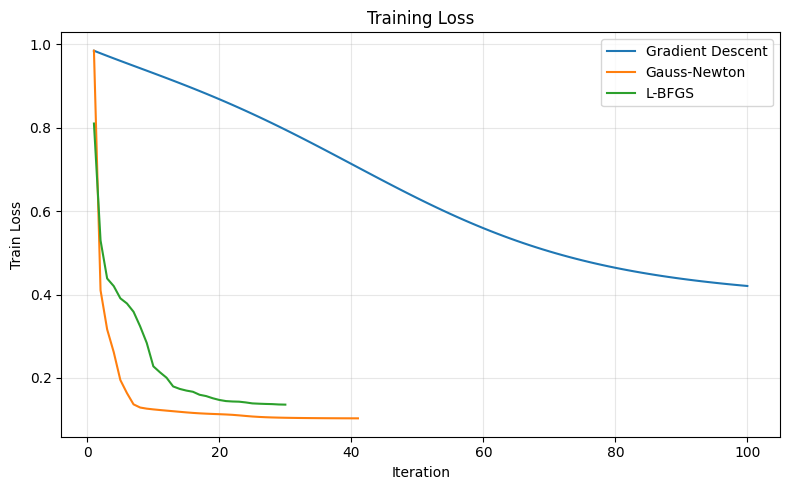

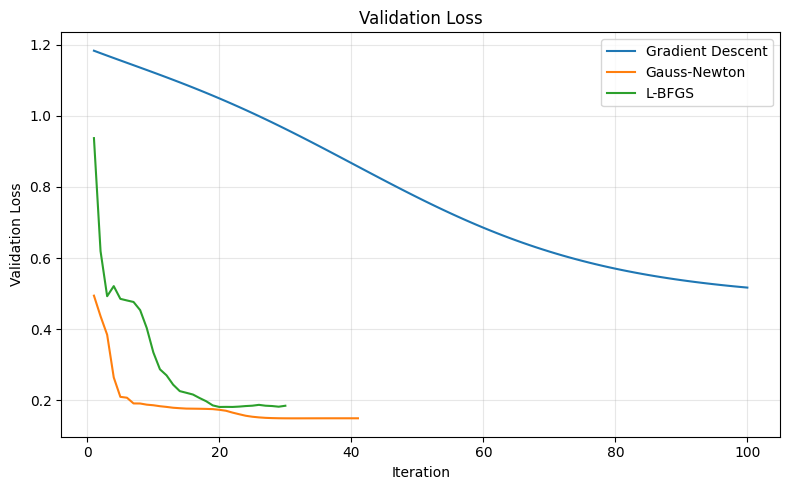

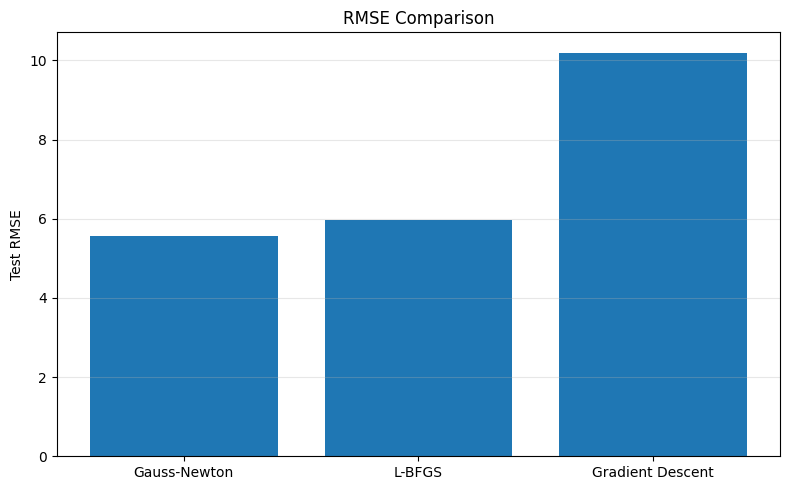

In [5]:
plt.figure(figsize=(8, 5))
for name in history_df["optimizer"].unique():
    p = history_df[history_df["optimizer"] == name]
    plt.plot(p["iteration"], p["train_loss"], label=name)
plt.xlabel("Iteration")
plt.ylabel("Train Loss")
plt.title("Training Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "loss_train.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
for name in history_df["optimizer"].unique():
    p = history_df[history_df["optimizer"] == name]
    plt.plot(p["iteration"], p["val_loss"], label=name)
plt.xlabel("Iteration")
plt.ylabel("Validation Loss")
plt.title("Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "loss_val.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(summary_df["optimizer"], summary_df["test_rmse"])
plt.ylabel("Test RMSE")
plt.title("RMSE Comparison")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "rmse_comparison.png", dpi=200)
plt.show()

In [6]:
print(WORKING_DIR / "optimizer_history.csv")
print(WORKING_DIR / "optimizer_summary.csv")
print(WORKING_DIR / "all_predictions_and_residuals.csv")
print(WORKING_DIR / "experiment_config.csv")
print(WORKING_DIR / "report_ringkas.md")
print(PLOTS_DIR)

/kaggle/working/optimizer_history.csv
/kaggle/working/optimizer_summary.csv
/kaggle/working/all_predictions_and_residuals.csv
/kaggle/working/experiment_config.csv
/kaggle/working/report_ringkas.md
/kaggle/working/plots
